# Simple Grid World: Approximation

## Installation and Setup

You need:
* Gymnasium (see [Installation Instructions](../common/Setup_Gymnasium.ipynb))
* Patched `gym-classics-1.0.0+internal.rev1` or later (see [Installation instructions](../common/Setup_patched_gym_classics.ipynb))

In [1]:
import numpy as np
np.set_printoptions(precision=2)

In [2]:
import gymnasium as gym
import gym_classics
gym_classics.register('gymnasium')

## Define an Empty 5x5 Grid 

A maze without walls. The step cost is 1. The start is (0,0) and
the goal (+100 reward) is (4,4).
This is the ideal problem for a linear approximation of the Q-function
using the x/y location as state features.

In [3]:
from gym_classics.envs.abstract.gridworld import Gridworld

class EmptyGridworld(Gridworld):
    layout = """
|    G|
|     |
|     |
|     |
|S    |
"""

    def __init__(self, tabular=True):
        super().__init__(self.layout, tabular=tabular)

    def _reward(self, state, action, next_state):
        if state in self._goals:
            return 0.0
        return {(4, 4): 100.0}.get(next_state, -1)

    def _done(self, state, action, next_state):
        return next_state in self._goals   

gym.register('EmptyGridworld-v1', entry_point=EmptyGridworld)

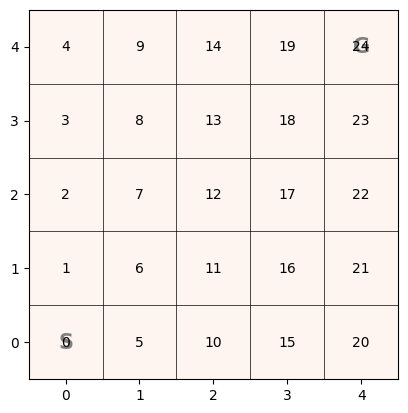

In [4]:
gym_env = gym.make('EmptyGridworld-v1', tabular = False)
env = gym_env.unwrapped

env.image()

In [5]:
from gym_classics.algorithms.monte_carlo_methods import sample_episode

sample_episode(env, max_len=1000)

[((0, 0), np.int64(0), -1, (0, 1)),
 ((0, 1), np.int64(2), -1, (0, 0)),
 ((0, 0), np.int64(1), -1, (1, 0)),
 ((1, 0), np.int64(0), -1, (1, 1)),
 ((1, 1), np.int64(3), -1, (0, 1)),
 ((0, 1), np.int64(2), -1, (0, 0)),
 ((0, 0), np.int64(2), -1, (0, 0)),
 ((0, 0), np.int64(1), -1, (1, 0)),
 ((1, 0), np.int64(1), -1, (2, 0)),
 ((2, 0), np.int64(0), -1, (2, 1)),
 ((2, 1), np.int64(2), -1, (2, 0)),
 ((2, 0), np.int64(3), -1, (1, 0)),
 ((1, 0), np.int64(2), -1, (1, 0)),
 ((1, 0), np.int64(3), -1, (0, 0)),
 ((0, 0), np.int64(3), -1, (0, 0)),
 ((0, 0), np.int64(0), -1, (0, 1)),
 ((0, 1), np.int64(0), -1, (0, 2)),
 ((0, 2), np.int64(1), -1, (1, 2)),
 ((1, 2), np.int64(1), -1, (2, 2)),
 ((2, 2), np.int64(1), -1, (3, 2)),
 ((3, 2), np.int64(2), -1, (3, 1)),
 ((3, 1), np.int64(3), -1, (2, 1)),
 ((2, 1), np.int64(3), -1, (1, 1)),
 ((1, 1), np.int64(3), -1, (0, 1)),
 ((0, 1), np.int64(1), -1, (1, 1)),
 ((1, 1), np.int64(3), -1, (0, 1)),
 ((0, 1), np.int64(3), -1, (0, 1)),
 ((0, 1), np.int64(2), -1, (

## State Features

We use here simply the x and y-coordinates as the state feature vector $\mathbf{x}(s)$. We also add an intercept (a 1) to the beginning so we end up with a 3-dimensional state feature.

`[intercept (always 1), x, y]`


In [6]:
def state_features(s, env):
    coord = s
    return np.concatenate([np.array([1]), np.array(coord)])

In [7]:
display(state_features((0, 0), env))
display(state_features((0, 1), env))

array([1, 0, 0])

array([1, 0, 1])

Linear approximation of the value function just means we calculate a weighted sum of the state feature components:

$\hat{v}(s,\mathbf{w}) = \mathbf{w}^\top \mathbf{x}(s)$, 

where $\mathbf{w}$ is the weight vector we want to learn.

In [8]:
def v_hat(s, w, env):
    x_s = state_features(s, env)
    return np.dot(w, x_s)

For example, I manually define here a weight vector.

In [9]:
w = np.array([1, 5, 20])

This means the smallest value at $(0,0)$ is the intercept of 1 and the value function increases by 5 for every step in the x direction and by
20 in the y direction.

In [10]:

print (f" v_hat((0,0), w) = {v_hat((0,0), w, env)}")
print (f" v_hat((1,1), w) = {v_hat((1,1), w, env)}")

 v_hat((0,0), w) = 1
 v_hat((1,1), w) = 26


Here is the value function for the weights evaluated on the states.

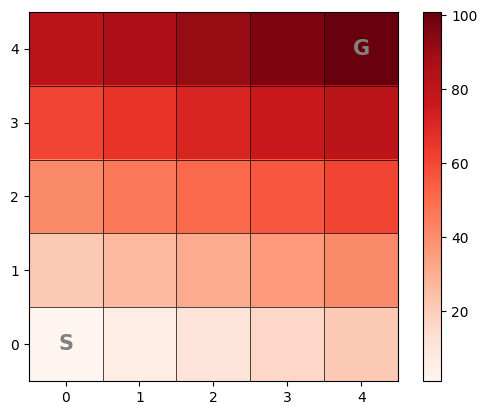

In [11]:
V = np.array([v_hat(env.id2state(s), w, env) for s in env.states()])
env.image(V)

We can visualize the manually created value function using contours.

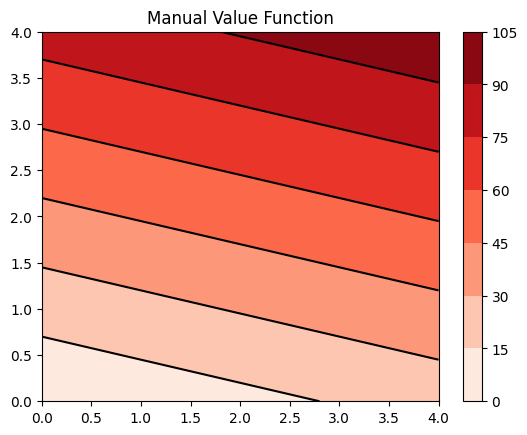

In [12]:
from matplotlib import pyplot as plt

def v_hat_grid(x, y, w):
    return np.dot(w, [1, x, y])

x = np.linspace(0, 4, 100)
y = np.linspace(0, 4, 100)
X, Y = np.meshgrid(x, y)

Z = np.array([v_hat_grid(x, y, w) for x, y in zip(np.ravel(X), np.ravel(Y))]).reshape(X.shape)

plt.contourf(X, Y, Z, cmap='Reds')
plt.title("Manual Value Function")
plt.colorbar()
plt.contour(X, Y, Z, colors='black') # Contour lines
plt.show()

# Estimation: Learning w for a given Policy 


We want to minimize the mean square value error: $\overline{VE} = \sum_{s\in \mathcal{S}} \mu(s) [v_\pi - \hat{v}(s, \mathbf{w})]^2$

This leads to:

* SGD update: $\mathbf{w}_{t+1} = \mathbf{w}_t + \alpha (U_t - \hat{v}(S_t, \mathbf{w}_t)) \mathbf{x}(S_t)$
* Gradient: $\nabla \hat{v}(s, \mathbf{w}) = \mathbf{x}(s)$


We could use the gradient Monte Carlo algorithm, but we show here the
Semi-Gradient TD(0) Algorithm with Linear Function Approximation.



![Semi-Gradient TD(0)](https://raw.githubusercontent.com/mhahsler/Introduction_to_Reinforcement_Learning/refs/heads/main/figures/RL-Intro_Alg_Semi_gradient_TD0.png)

In [13]:
from tqdm import tqdm

def semi_gradient_TD0_estimation(env, policy, n, alpha, gamma, max_episode_length=100, verbose = True):
    assert isinstance(env, gym.Env), "env must be an instance of gym.Env"
    assert alpha > 0 and alpha <= 1, "Alpha must be in (0,1]"
    assert gamma >= 0 and gamma <= 1, "Gamma must be in [0,1]"
    assert n > 0, "Number of episodes must be positive"
    assert max_episode_length > 0, "Max episode length must be positive"
    
    w = np.zeros(len(state_features(env.id2state(0), env)))  # Initialize weights (intercept + x and y)

    for episode in tqdm(range(n), desc="Episodes", disable=verbose):
        state, _ = env.reset()
        done = False

        i = 0
        while not done and i < max_episode_length:
            action = policy[state]  # follow policy
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            
            # Semi-gradient TD(0) update
            # Note: v_hat(terminal, w) needs to be 0
            if terminated:
                w += alpha * (reward - v_hat(state, w, env)) * state_features(state, env)    
            else: 
                w += alpha * (reward + gamma * v_hat(next_state, w, env) - v_hat(state, w, env)) * state_features(state, env)
             
            if verbose:
                print (f"Episode {episode+1}, Step {i+1}: S={state}, A={action}, R={reward}, S'={next_state}, w={w}")

            state = next_state
            i += 1

    return w

I will manually create a policy to evaluate.

In [14]:
from gym_classics.algorithms.policy import make_multidiscrete_policy

pol = np.full(len(env.states()), env.action2id('up'))
pol[[4, 9, 14, 19]] = env.action2id('right')
pol

pol = make_multidiscrete_policy(pol, env)
pol

{(0, 0): np.int64(0),
 (0, 1): np.int64(0),
 (0, 2): np.int64(0),
 (0, 3): np.int64(0),
 (0, 4): np.int64(1),
 (1, 0): np.int64(0),
 (1, 1): np.int64(0),
 (1, 2): np.int64(0),
 (1, 3): np.int64(0),
 (1, 4): np.int64(1),
 (2, 0): np.int64(0),
 (2, 1): np.int64(0),
 (2, 2): np.int64(0),
 (2, 3): np.int64(0),
 (2, 4): np.int64(1),
 (3, 0): np.int64(0),
 (3, 1): np.int64(0),
 (3, 2): np.int64(0),
 (3, 3): np.int64(0),
 (3, 4): np.int64(1),
 (4, 0): np.int64(0),
 (4, 1): np.int64(0),
 (4, 2): np.int64(0),
 (4, 3): np.int64(0),
 (4, 4): np.int64(0)}

In [15]:
w = semi_gradient_TD0_estimation(env, pol, n=5000, alpha=0.01, gamma=1, verbose=False)
w

Episodes:  36%|███▌      | 1785/5000 [00:02<00:02, 1119.45it/s]

Episodes: 100%|██████████| 5000/5000 [00:09<00:00, 552.87it/s] 


array([93.,  1.,  1.])

It learns correctly that increasing x or y increases the value by 1 (the step cost) and that we start in $(0,0)$ with a value of 93.

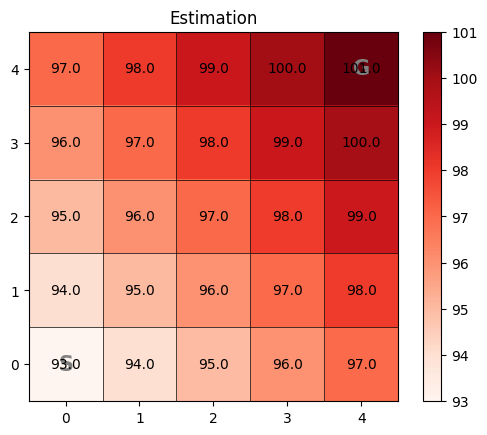

In [16]:
V = np.array([v_hat(env.id2state(s), w, env) for s in env.states()])
env.image(V, title = "Estimation", labels=True)

Show the continuous value function.

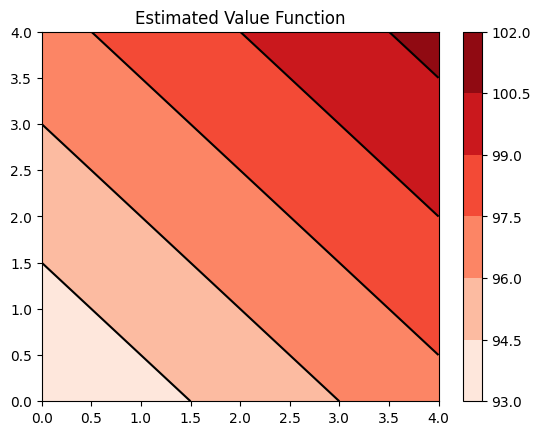

In [17]:
from matplotlib import pyplot as plt

def v_hat_grid(x, y, w):
    return np.dot(w, [1, x, y])

x = np.linspace(0, 4, 100)
y = np.linspace(0, 4, 100)
X, Y = np.meshgrid(x, y)

Z = np.array([v_hat_grid(x, y, w) for x, y in zip(np.ravel(X), np.ravel(Y))]).reshape(X.shape)

plt.contourf(X, Y, Z, cmap='Reds')
plt.title("Estimated Value Function")
plt.colorbar()
plt.contour(X, Y, Z, colors='black') # Contour lines
plt.show()


&copy; 2025 [Michael Hahsler](http://michael.hahsler.net). 
This work is openly licensed under [Creative Commons Attribution-ShareAlike 4.0 International (CC BY-SA 4.0) License](https://creativecommons.org/licenses/by-sa/4.0/)

![CC BY-SA 4.0](https://licensebuttons.net/l/by-sa/3.0/88x31.png)